PCA算法练习  
说明：  
1.写代码时请先读完整体代码，了解整体思路和结构后再进行编程  
2.同学们可以阅读当前目录下的pdf文档，里面有关于本次任务的讲解  
3.代码的其他部分不需要更改，只需填充上所给出的代码块，否则会影响评判。  
  <b>需要填空的地方格式如下：  </b>  
  \###### start ######  

  \######  end  ######

![info](./info.png)

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt

In [2]:
# Generate two sets of 3D data, which can be roughly separated in 3D space
data1 = np.random.normal(loc=1, scale=1, size=(100, 3))
data2 = np.random.normal(loc=5, scale=1, size=(100, 3))
data = np.concatenate((data1, data2), axis=0)
print(data1.shape, data2.shape, data.shape)

(100, 3) (100, 3) (200, 3)


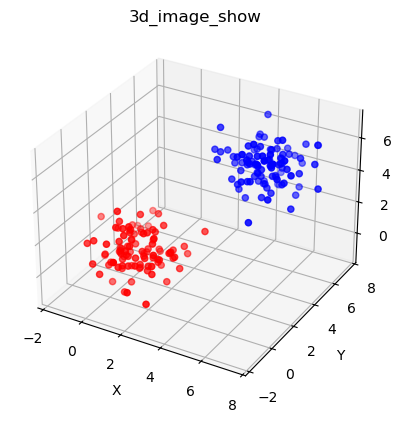

In [3]:
# show data
ax = plt.subplot(projection = '3d')  # Create a 3D drawing project
ax.set_title('3d_image_show')  # set title
ax.scatter(data[0:100, 0], data[0:100, 1], data[0:100, 2], c = 'r') # plot data1
ax.scatter(data[100:200, 0], data[100:200, 1], data[100:200, 2], c = 'b') # plot data2
 
ax.set_xlabel('X') # set x-axis
ax.set_ylabel('Y') # set y-axis
ax.set_zlabel('Z') # set z-axis
 
plt.show()

In [13]:
def PCA(X , num_components):
     
    #Step-1
    # ######## start #########
    X_meaned = X - np.mean(X, axis=0)# tip: use np.mean()
    # ########  end  #########
    
    #Step-2
    # ######## start #########
    cov_mat = np.cov(X_meaned, rowvar=False) # tip: use np.cov() to compute cov, please set rowvar=False in np.cov
    # ########  end #########
    
    #Step-3
    # ######## start #########
    # tip: use np.linalg.eigh to compute eigen_values and eigen_vectors.
    # if you don't konw how to use np.linalg.eigh and what np.linalg.eigh used for, \
    # please learn it in https://blog.csdn.net/qq_38048756/article/details/112543075
    eigen_values , eigen_vectors = np.linalg.eigh(cov_mat)
    # ########  end  #########
    
    #Step-4
    # ######## start #########
    sorted_index = np.argsort(eigen_values)[::-1] # return the index of eigen_values sorted from large to small
    sorted_eigenvectors = eigen_vectors[:, sorted_index] # use sorted_index to sort eigen_vectors
    # ########  end #########
     
    #Step-5
    # ######## start #########
    eigenvector_subset = sorted_eigenvectors[:, :num_components] # Keep the eigenvectors corresponding to the first N largest eigenvalues
    # ######## end #########
     
    #Step-6
    # Convert the original features to the new space constructed by the N feature vectors above
    X_reduced = np.dot(eigenvector_subset.transpose() , X_meaned.transpose() ).transpose()
     
    return X_reduced

In [14]:
######## start #########
# use PCA function we just wrote to compress the data dimension
# please set num_components=2 in PCA
mat_reduced = PCA(data, num_components=2)
########  end  #########
print(mat_reduced.shape)

(200, 2)


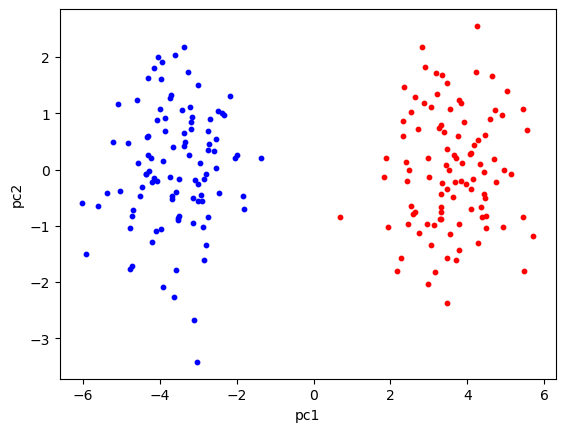

In [15]:
plt.figure()

plt.scatter(mat_reduced[0:100, 0],mat_reduced[0:100, 1], s=10, c='r') # plot mat_reduced
plt.scatter(mat_reduced[100:200, 0],mat_reduced[100:200, 1], s=10, c='b') # plot mat_reduced
 
plt.xlabel('pc1')  # set the label of x
plt.ylabel('pc2')  # set the label of y
 
plt.show()